#Problem 1

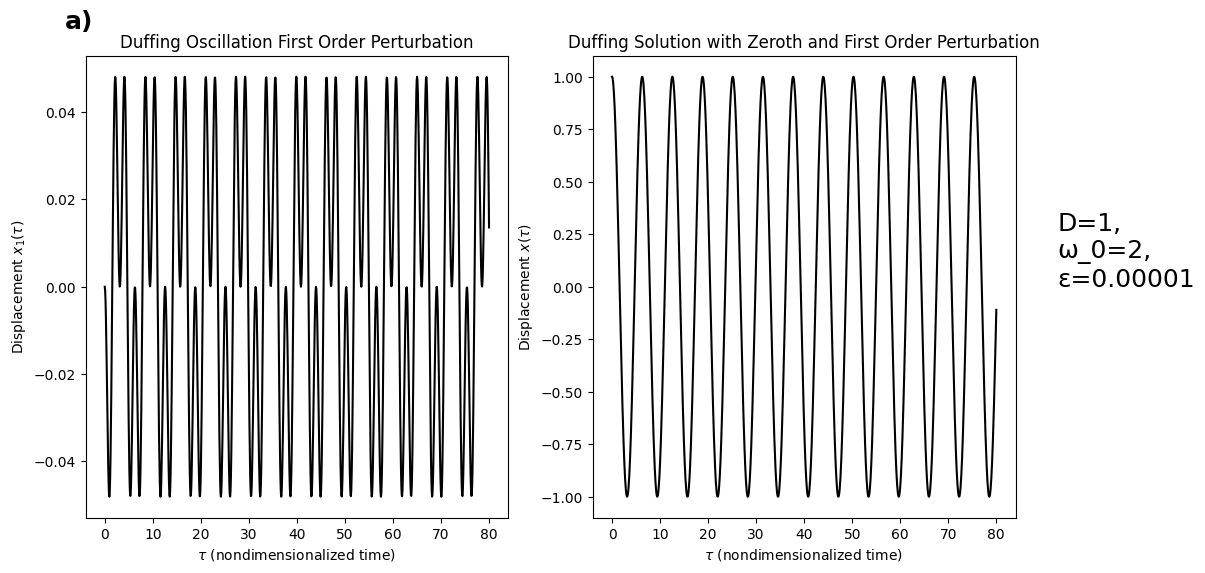

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy
import matplotlib.ticker # Import ticker for AutoMinorLocator

# Create figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

#Define variables + constants (with simple values)
t = np.linspace(0,40, 1000)
D = 1
omega_0 = 2
epsilon = 1e-5

#Define the complete solution x and the first order perturbation x_1

def duffing_first_order(tau, D):
  return D/32*(np.cos(3*tau) - np.cos(tau))


def duffing(t, D, epsilon):
  return D*np.cos(t) + (D**2)*epsilon*duffing_first_order(t, D)


#Define omega and its first order perturbation

def omega_first_order(omega_0, D):
  return (3*omega_0)/8

def omega(omega_0, D, epsilon):
  return omega_0 + epsilon*(D**2)*omega_first_order(omega_0, D)

#Define omegas in order to turn tau into units of time
omega_sol_first_ord = omega_first_order(omega_0, D)
omega_sol = omega(omega_0, D, epsilon)

t_sol = t * omega_sol

#Define solutions x and x_1 with dimensional time t

duffing_sol_first_ord = duffing_first_order(t_sol, D)


duffing_sol = duffing(t_sol, D, epsilon)


#Plot curve of just first order perturbations
ax1.plot(t_sol, duffing_sol_first_ord,
        color='black')

ax1.set_xlabel(r'$\tau$ (nondimensionalized time) ')
ax1.set_ylabel(r'Displacement $x_1(\tau)$')
ax1.set_title(r'Duffing Oscillation First Order Perturbation')
ax1.text(-0.05, 1.1, 'a)', transform=ax1.transAxes, fontsize=18, fontweight='bold', va='top')

#Plot curve of Duffing solution WITH first order perturbations
ax2.plot(t_sol, duffing_sol,
        color='black')

ax2.set_xlabel(r'$\tau$ (nondimensionalized time) ')
ax2.set_ylabel(r'Displacement $x(\tau)$')
ax2.set_title(r'Duffing Solution with Zeroth and First Order Perturbation')
ax2.text(1.1, 0.5, 'D=1,\nω_0=2,\nε=0.00001', transform=ax2.transAxes, fontsize=18)


plt.show()

##Problem 4

Part c

/tmp/ipykernel_1450/4281522344.py:53: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X0, X1, dX0/M, dX1/M, color='b')
/tmp/ipykernel_1450/4281522344.py:70: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(0, 0, 'ko', color = 'blue', markersize=8, label='equilibria 1')
/tmp/ipykernel_1450/4281522344.py:71: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ks" (-> color='k'). The keyword argument will take precedence.
  ax.plot(-1, -1, 'ks', color = 'black', markersize=6, label='equilibria 2')


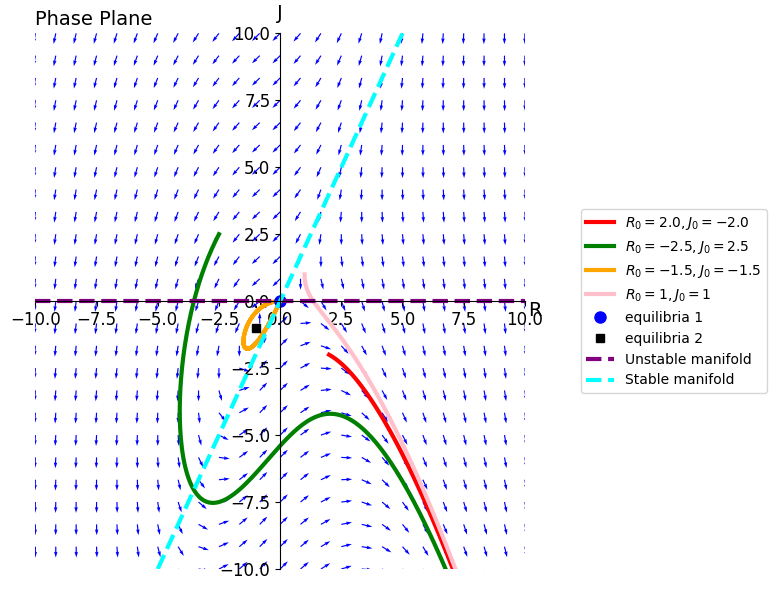

In [ ]:
##Note: The code for the phase plane and state-space trajectory is taken from:
#https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/#google_vignette$0

import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy as np

def dynamicsStateSpace(x, t):
    dxdt = [-x[1] + x[0], -(x[0]**2) - x[1]]
    return dxdt

from scipy.integrate import solve_ivp

def f(t, x):
    return [x[0] - x[1], -x[0]**2 - x[1]]

def leave_box(t, x):
    return 10 - max(abs(x[0]), abs(x[1]))
leave_box.terminal = True
leave_box.direction = -1

# grid of points for the quiver field
x0 = np.linspace(-10, 10, 25)
x1 = np.linspace(-10, 10, 25)
X0, X1 = np.meshgrid(x0, x1)
dX0 = np.zeros(X0.shape)
dX1 = np.zeros(X1.shape)

sR, sJ = (1, 1)

shape1, shape2 = X1.shape
for indexShape1 in range(shape1):
    for indexShape2 in range(shape2):
        dxdtAtX = dynamicsStateSpace(
            [X0[indexShape1, indexShape2], X1[indexShape1, indexShape2]], 0
        )
        dX0[indexShape1, indexShape2] = dxdtAtX[0]
        dX1[indexShape1, indexShape2] = dxdtAtX[1]

M = (dX0**2 + dX1**2)**0.5

initial_states = [
    (2.0, -2.0),
    (-2.5, 2.5),
    (-1.5, -1.5),
    (1, 1),
]
colors = ['r', 'g', 'orange', 'pink']
simulationTime = np.linspace(0, 50, 1000)

fig, ax = plt.subplots(figsize=(8, 6))

ax.quiver(X0, X1, dX0/M, dX1/M, color='b')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

for (R0, J0), c in zip(initial_states, colors):
    sol = solve_ivp(f, [0, 50], [R0, J0], events=leave_box,
                    t_eval=np.linspace(0, 50, 5000),
                    rtol=1e-9, atol=1e-9)
    R, J = sol.y

    # add the exact exit point so the curve reaches the edge cleanly
    if sol.t_events[0].size:
        R = np.append(R, sol.y_events[0][0][0])
        J = np.append(J, sol.y_events[0][0][1])

    ax.plot(R, J, color=c, linewidth=3, label=rf'$R_0={R0}, J_0={J0}$')

ax.plot(0, 0, 'ko', color = 'blue', markersize=8, label='equilibria 1')
ax.plot(-1, -1, 'ks', color = 'black', markersize=6, label='equilibria 2')

#Plot manifolds
plt.axhline(y=0, color='purple', linestyle='--', label='Unstable manifold', linewidth=3)
plt.axline((0, 0), slope=2, color='aqua', linestyle='--', label='Stable manifold', linewidth=3)


# --- move the axes to cross at the origin, like a coordinate plane ---
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# put tick marks only on the bottom/left (now centered) spines
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.set_title('Phase Plane', fontsize=14, loc='left')
# label axes near the arrow ends instead of the usual outer position
ax.set_xlabel('R', fontsize=14)
ax.xaxis.set_label_coords(1.02, 0.5)
ax.set_ylabel('J', fontsize=14, rotation=0)
ax.yaxis.set_label_coords(0.5, 1.02)

ax.tick_params(axis='both', which='major', labelsize=12)

ax.legend(fontsize=10, loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.tight_layout()
plt.show()